# Lab 3 - Local evidence of climate change

## Testing the hypothesis: Attributes of weather have changed in the last 70 years in the vicinity of Heathrow airport.

You can get historic readings from UK weather stations <a href="https://www.metoffice.gov.uk/research/climate/maps-and-data/historic-station-data">UK Met Office</a> The most local is from Ringway (aka Manchester Airport), but this weather station closed in 2004. You will use data from Heathrow airport which runs through January 2023. Some data starts in 1948; others start later. This has been downloaded for you. 

The data is index by months and years. For each month, the data contains five attributes: minimum and maximum temperature (C&deg;) within each month, number of days with air frost per month, millimeters of rain in each month, and hours of sunshine  each month. 

I want you to find out if each of these attributes shows signs of change individually. For each attribute, find the statistical evidence of change or no change. In other words, you will test five hypotheses, one for each attribute. They will be of the form:
<br><br>
<center>The value of attribute X was higher/lower/different before year YYYY than after.</center>
<br>
It is up to you to decide what the dividing year should be, and whether it should be an upper-tail, lower-tail, or two-tail test. You can probably use the same dividing year for all five attributes. 

You may use any valid statistical method such as t/Z tests or bootstrapping. Whatever method you use, you will use it on five different datasets, so I encourage you to create reusable functions to save typing or cut-pasting. 

## 1. Preliminaries

#### Imports (add as needed)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

#### Get the data

Read in the data to a pandas DataFrame

In [35]:
df = pd.read_csv("Heathrow Weather Data.csv")
df

,yyyy,month,tmax C,tmin C,air frost (days),rain (mm),sun (hours)
0,1948,1,8.9,3.3,---,85.0,---
1,1948,2,7.9,2.2,---,26.0,---
2,1948,3,14.2,3.8,---,14.0,---
3,1948,4,15.4,5.1,---,35.0,---
4,1948,5,18.1,6.9,---,57.0,---
...,...,...,...,...,...,...,...
896,2022,9,20.2,11.8,0,86.0,119.1
897,2022,10,18.3,10.4,0,81.4,132.8
898,2022,11,13.2,7.6,0,123.8,69.9
899,2022,12,7.9,1.7,11,50.2,56.4


## 2. Clean the data - 2 marks

Examine the data. You will observe several issues

1. Do all the attributes start and end at the time? If not, record the start and end times so you can refer to the entire sequence of that attribute. Store in some data structure. 

2. Are all the attributes floats or are some strings? You need them to be floats. Convert if necessary. 

**Fix these issues and any others you find.**

### 2a. When year does the data start?

For each attribute, find the starting year and its index. Store in a data structure such as a dictionary. 

In [36]:
start_years = {}
for col in df.columns:
    i=0
    while True:
        if df[col].iloc[i] != "---":
            start_years[col] = df["yyyy"].iloc[i]
            break
        i+=1
    continue
start_years

{'yyyy': np.int64(1948),
 'month': np.int64(1948),
 'tmax C': np.int64(1948),
 'tmin C': np.int64(1948),
 'air frost (days)': np.int64(1949),
 'rain (mm)': np.int64(1948),
 'sun (hours)': np.int64(1957)}

### 2b Convert any numbers represented as strings to floats. 

In order to produce plots, all numbers must be represented as floats or integers. 

In [37]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(float).fillna(0.0)

df.dtypes

yyyy                float64
month               float64
tmax C              float64
tmin C              float64
air frost (days)    float64
rain (mm)           float64
sun (hours)         float64
dtype: object

### Report on cleaning the data.
Summarize what you did in the box below

- Iterated through each row until the data did not read "---". Stored the corresponding year in a dictionary, with the key as the attribute, for each attribute.
- Iterated through each column to convert into the float data type. This also cleaned the data of NaN values by converting every non-float into 0.

## Wrangle the data - 2 marks

Observe the way time is represented, by year and month number with in that year. That is not convenient for producing plots and other visualizations. Create a column in the DataFrame which measures time in absolute months since January 1948. Display the first few rows and the last few rows of the DataFrame to show that you have does this. 

In [38]:
df["abs_months"]=df.index

df


,yyyy,month,tmax C,tmin C,air frost (days),rain (mm),sun (hours),abs_months
0,1948.0,1.0,8.9,3.3,0.0,85.0,0.0,0
1,1948.0,2.0,7.9,2.2,0.0,26.0,0.0,1
2,1948.0,3.0,14.2,3.8,0.0,14.0,0.0,2
3,1948.0,4.0,15.4,5.1,0.0,35.0,0.0,3
4,1948.0,5.0,18.1,6.9,0.0,57.0,0.0,4
...,...,...,...,...,...,...,...,...
896,2022.0,9.0,20.2,11.8,0.0,86.0,119.1,896
897,2022.0,10.0,18.3,10.4,0.0,81.4,132.8,897
898,2022.0,11.0,13.2,7.6,0.0,123.8,69.9,898
899,2022.0,12.0,7.9,1.7,11.0,50.2,56.4,899


## 3. Explore and visualize the data

- Plot each attribute to see if there is visual evidence of change over time. 

- Determine whether there is visual evidence that the data is from a normal distribution. (Does the data look normally distributed?)

- Do any other visualization which you deem useful.

- **Label the axis of your graphs.** 

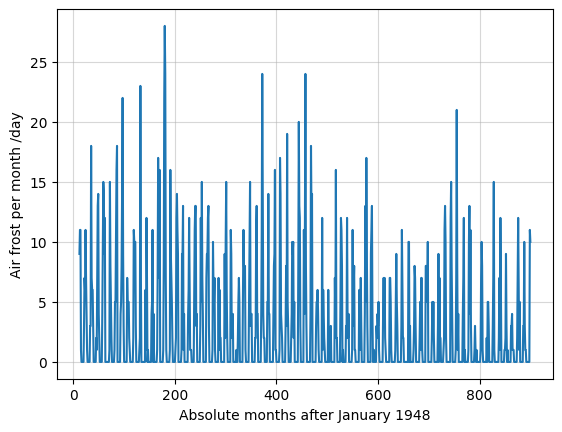

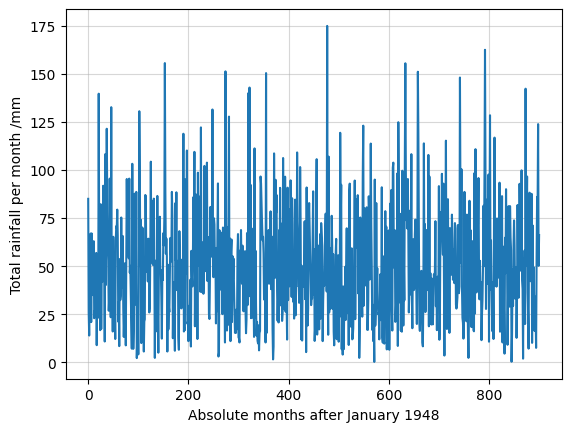

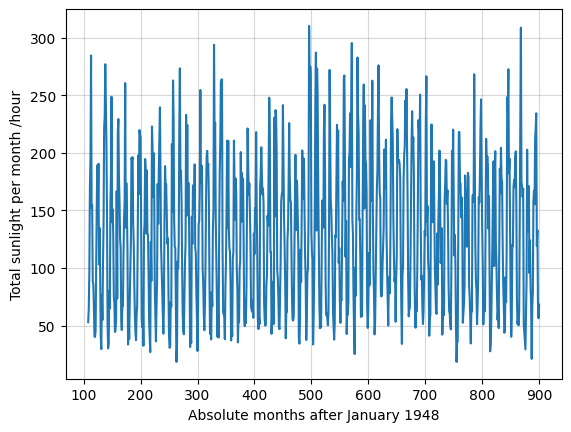

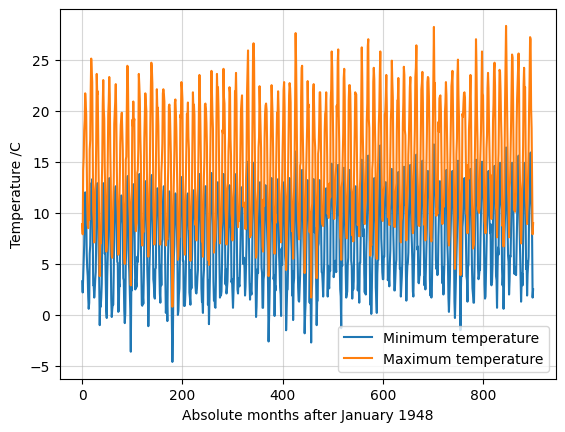

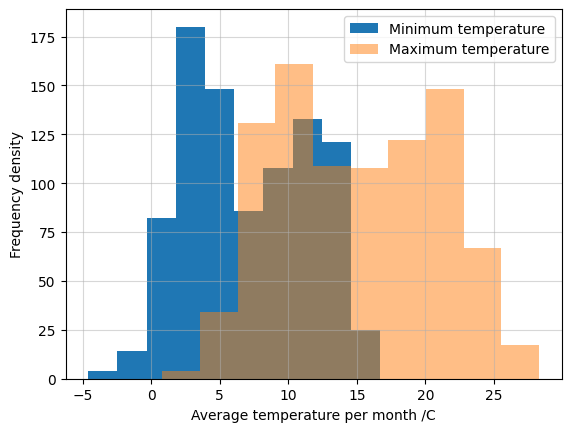

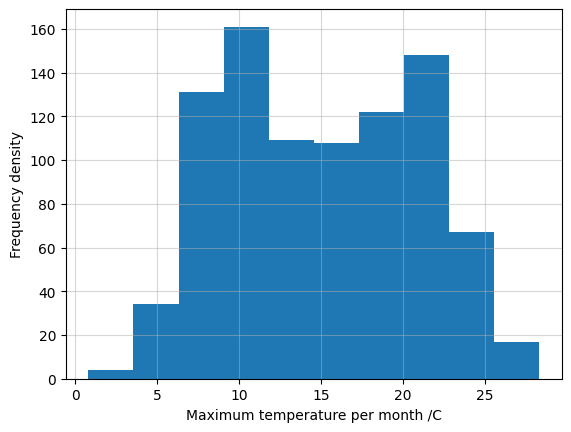

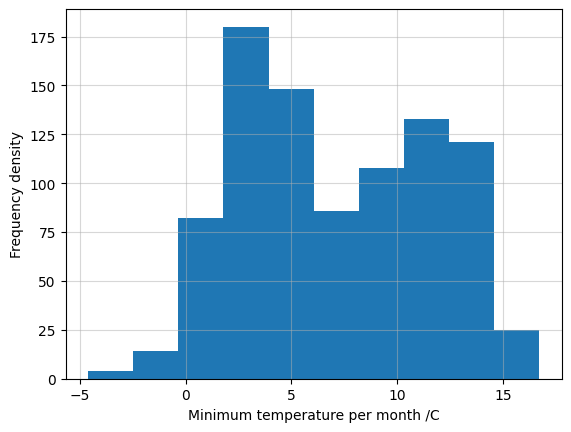

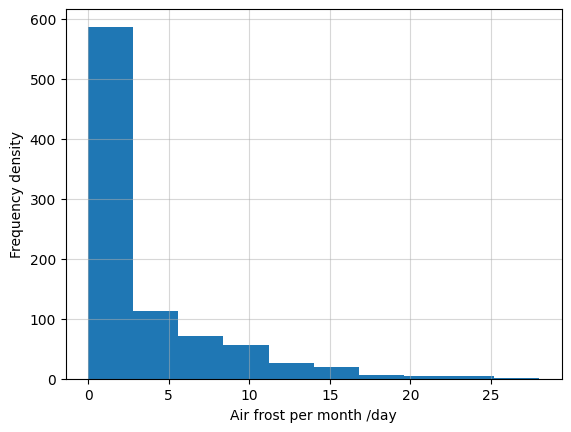

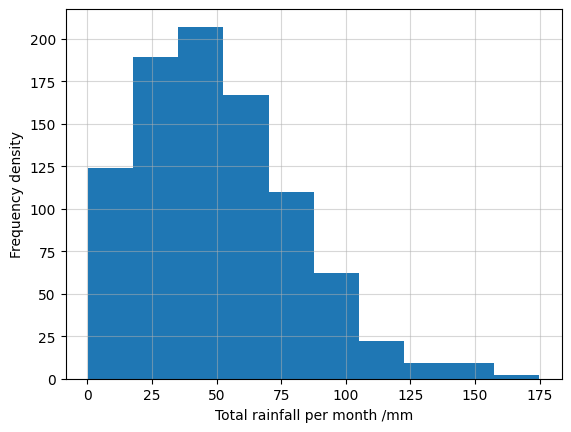

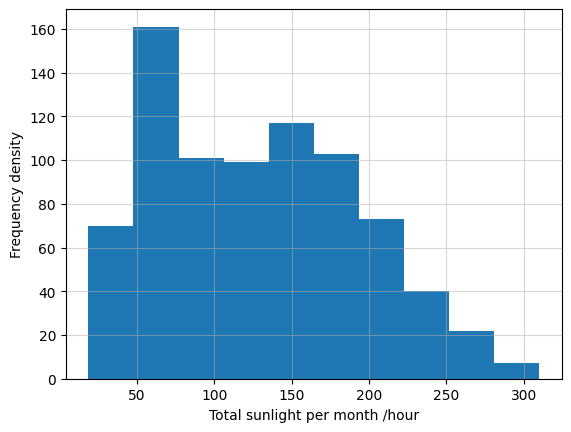

In [39]:
label = {"tmin C": "Minimum temperature per month /C",
         "tmax C": "Maximum temperature per month /C",
         "air frost (days)": "Air frost per month /day",
         "rain (mm)": "Total rainfall per month /mm",
         "sun (hours)": "Total sunlight per month /hour"}

for col in df.columns[4:-1]:
    data = df[col][df["yyyy"] >= start_years[col]]
    abs_months = df["abs_months"][df["yyyy"] >= start_years[col]]
    plt.plot(abs_months, data)
    plt.xlabel("Absolute months after January 1948")
    plt.ylabel(label[col])
    plt.grid(alpha=0.5)
    plt.show()

min_temp = df["tmin C"][df["yyyy"] >= start_years["tmin C"]]
max_temp = df["tmax C"][df["yyyy"] >= start_years["tmax C"]]

plt.plot(df["abs_months"][df["yyyy"] >= start_years["tmin C"]], min_temp, label="Minimum temperature")
plt.plot(df["abs_months"][df["yyyy"] >= start_years["tmax C"]], max_temp, label="Maximum temperature")
plt.xlabel("Absolute months after January 1948")
plt.ylabel("Temperature /C")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.hist(min_temp, label="Minimum temperature")
plt.hist(max_temp, alpha=0.5, label="Maximum temperature")
plt.ylabel("Frequency density")
plt.xlabel("Average temperature per month /C")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

for col in df.columns[2:-1]:
    data = df[col][df["yyyy"] >= start_years[col]]
    abs_months = df["abs_months"][df["yyyy"] >= start_years[col]]
    plt.hist(data)
    plt.ylabel("Frequency density")
    plt.xlabel(label[col])
    plt.grid(alpha=0.5)
    plt.show()

### 3a. Summarize your findings in the box below for each attribute - 1 mark for each attribute.

Visual evidence of trend and normal distributions:
- Min temperature: shows a steady upward trend. Has two peak frequencies as opposed to one thus it is not a bell-curved normal distribution.
- Max temperature: shows the same upward trend as the min temperature over time. Amount higher than min temperature remains consistent. Also has two (different to minimum) peaks, thus it is unlikely to be from a normal distribution.
- Air frost: from unsmoothed data, this could show a gradual decrease in air frost each year. Frequency peaks by 0 and falls of with a low standard deviation, implying it could be normally distributed from mean 0 (without negative terms).
- Rainfall: does not seem to have an increasing or decreasing trend over time. Frequency peaks around 45mm and is a steady bell curve, thus implying it could be normally distributed.
- Sunlight: Has no increasing or decreasing trend over time. Frequency peaks around 60 hours but does not fall in line with the rest of the curve so it is not normally distributed.

## 4. Removal of seasonality and data smoothing

Any long-term change is hard to see by eye, because of the 12-month periodicity (winter, spring, summer, fall). Remove this to smooth the data. What is the best way to remove the seasonality and smooth the data.  

1. &#x2610; Average over months? How many months?

2. &#x2610; Use only a single month per year? Which one?

3. &#x2610; Some other method. Describe in the next box.


Discuss in the next box what method you used to smooth the data, and why you chose this.

## 2 marks

Each year contains 12 months (records) of data, so I will take the average of each of these 12 months per year for each attribute. This will allow us to see if each attribute has a visible trend yearly across 75 years. If an attribute had only a partial year's worth of data, the year will be disregarded, such as with 2023 which only has data for January.  Years with no data will be truncated off of the visualisations as to not skew trends.

## Plot the smoothed data to see if 

1. You see signs of change visually.

2. What absolute month the change took place (to help you decide where to divide the data).

Comment on this in the box below for each attribute.

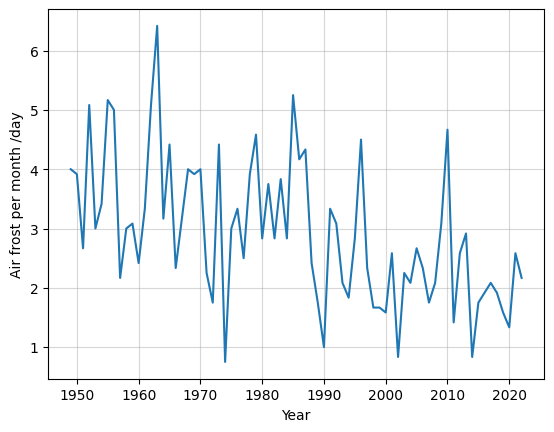

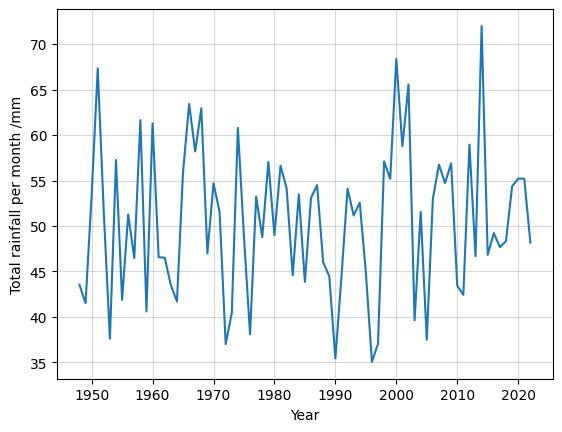

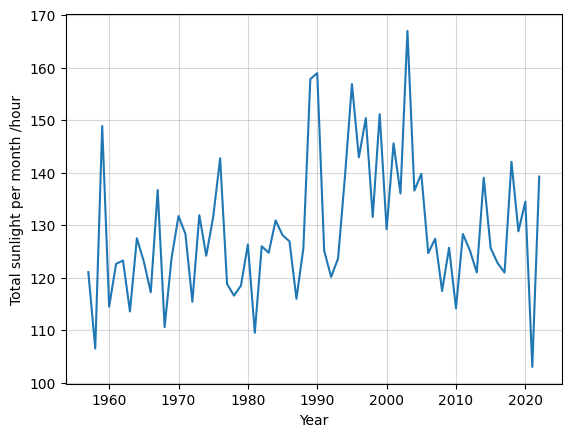

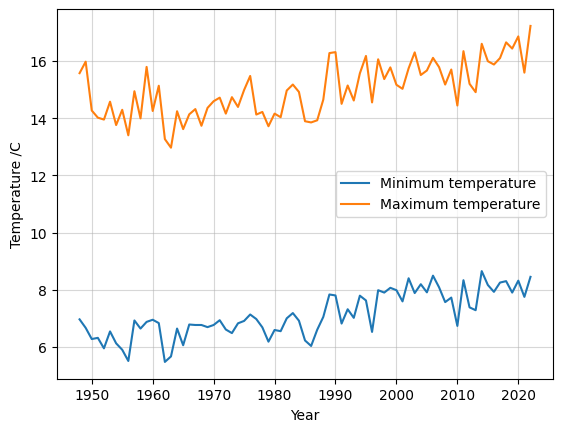

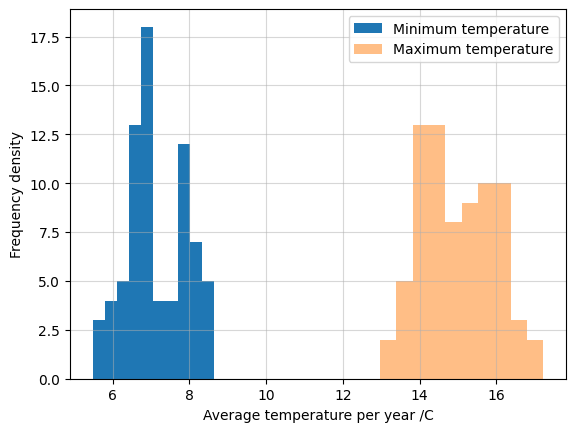

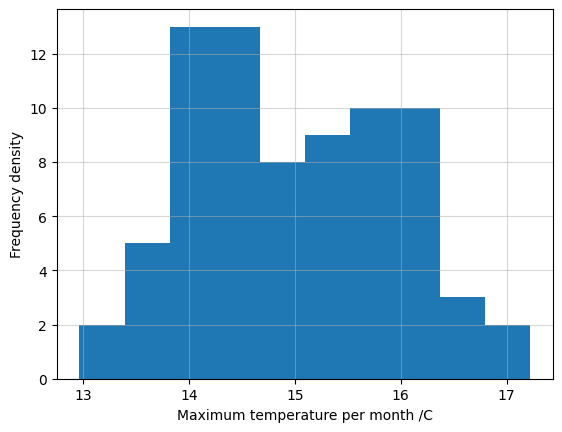

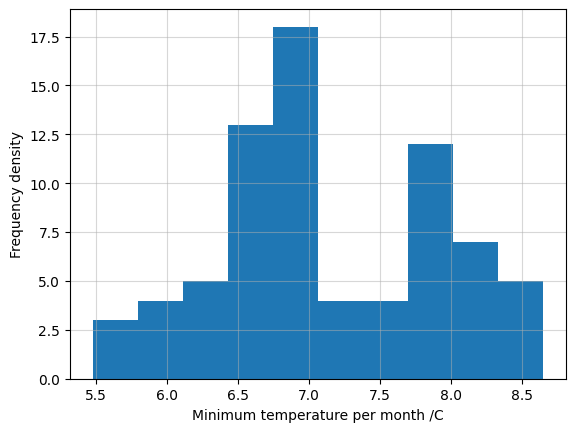

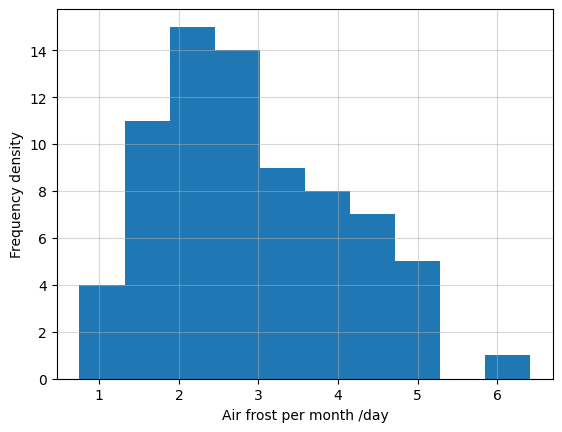

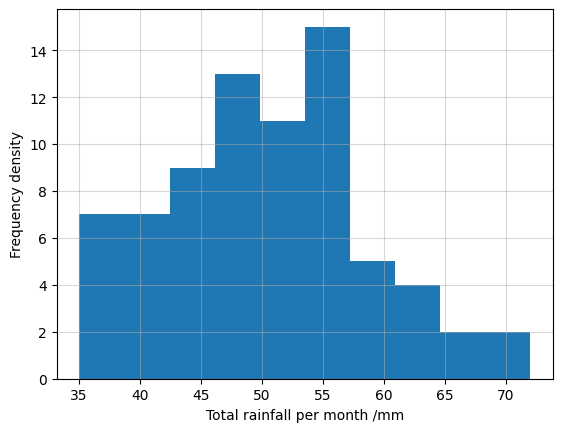

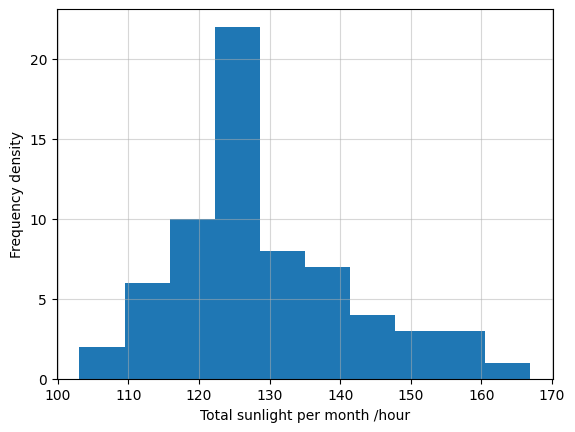

In [40]:
# remove 2023
df = df.iloc[1:-1]

for col in df.columns[4:-1]:
    filtered = df[col][df["yyyy"] >= start_years[col]]
    data_smooth = filtered.groupby(filtered.index // 12).mean()
    years = range(int(start_years[col]), int(start_years[col]) + len(data_smooth))
    plt.plot(years, data_smooth)
    plt.xlabel("Year")
    plt.ylabel(label[col])
    plt.grid(alpha=0.5)
    plt.show()

min_filtered = df["tmin C"][df["yyyy"] >= start_years["tmin C"]]
max_filtered = df["tmax C"][df["yyyy"] >= start_years["tmax C"]]
min_temp_smooth = min_filtered.groupby(min_filtered.index // 12).mean()
max_temp_smooth = max_filtered.groupby(max_filtered.index // 12).mean()

min_years = range(int(start_years["tmin C"]), int(start_years["tmin C"]) + len(min_temp_smooth))
max_years = range(int(start_years["tmax C"]), int(start_years["tmax C"]) + len(max_temp_smooth))
plt.plot(min_years, min_temp_smooth, label="Minimum temperature")
plt.plot(max_years, max_temp_smooth, label="Maximum temperature")
plt.xlabel("Year")
plt.ylabel("Temperature /C")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.hist(min_temp_smooth, label="Minimum temperature")
plt.hist(max_temp_smooth, alpha=0.5, label="Maximum temperature")
plt.ylabel("Frequency density")
plt.xlabel("Average temperature per year /C")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

for col in df.columns[2:-1]:
    filtered = df[col][df["yyyy"] >= start_years[col]]
    data_smooth = filtered.groupby(filtered.index // 12).mean()
    plt.hist(data_smooth)
    plt.ylabel("Frequency density")
    plt.xlabel(label[col])
    plt.grid(alpha=0.5)
    plt.show()

New visible trends in the data:
- Min temperature: a steady upwards trend is now visible. The two peaks are still distinctive so it is unlikely to be normally distributed. It now shares less data in common with the max temperatures.
Max temperature: follows the same consistent increase as the min temperature. Its peaks in frequency are less defined than min temperature's so it is more likely to be normally distributed, but this is unlikely. Temperatures peaked initially.
- Air frost: a steady downward trend is now visible, albeit still highly variable and gradual. Mean frequency has now shifted to around 3 days and has a larger standard deviation, suggesting it is more likely to be from a normal distribution.
- Rainfall: A slight increasing trend over years is visible. The frequency curve is uneven so rainfall is unlikely to be normally distributed.
- Sunlight: A slight increasing trend over years is visible. Frequency has a significant peak around 125 hours, similar to previously, which does not follow the rest of the curve. It is unlikely to be from a normal distribution.

Absolute month the change took place:
- Each attribute has a gradual trend without a specific month turning point, therefore the datasets will be split in half.

## 5. Perform the statistical test 

Divide the data into two parts; an early phase and a recent phase. You decide which year or absolute month should be chosen as the change point, or divide it in half.  Investigate statistically whether the two periods are statistically different or not for each attribute. **Use $\alpha$ value of $0.01$**. 


### 5a. Write code to perform the statistical test for any attribute.  4 marks
The comparison of two means depends on the two data sets, the $\alpha$-value and the type of test. Your task for this part is to write some code which will take as input the two dataset being compared, the alpha values, and the type of test. The output will be the result of the test. My solution is described below. Yours can be different, but should give similar results. 

**Jonathan's solution:**
Input: The dataframe,the starting index for the early data, the starting index for the recent data and the critical value. For a lower-tail test, the critical value will be negative; for a upper-tail test, the critical value will be positive, and for a two-tailed test, the critical value a list of two values, `[-c,c]`, where `c` are the values associated with $\alpha/2$ and $1-\alpha/2$. The output will give the value of the test statistics (which the code computes) the critical value, and the conclusion ('Reject the Null'/'Fail to reject the Null'). It also plotted the means with SEM errorbars. 

#### For help with computing critical values, see Appendix A.

<img src="https://www.dropbox.com/scl/fi/g6y5iomb6cwwqv6lak743/Example_output.png?rlkey=r933o6fzf27ydbb535aria34o&st=4hjzfqvj&raw=1">

In [41]:
def test(df, col, early_start, recent_start, critical_value):
    def to_pos(idx):
        try:
            return int(df.index.get_loc(idx))
        except KeyError:
            return int(idx)

    start_pos = to_pos(early_start)
    split_pos = to_pos(recent_start)

    early_data = df[col].iloc[start_pos:split_pos]
    recent_data = df[col].iloc[split_pos:]

    n1, n2 = len(early_data), len(recent_data)
    mean1, mean2 = early_data.mean(), recent_data.mean()

    # test statistic
    se = np.sqrt(early_data.var(ddof=1) / n1 + recent_data.var(ddof=1) / n2)
    test_stat = (mean2 - mean1) / se
    test_stat_rounded = round(float(test_stat), 2)

    # conclusion
    if isinstance(critical_value, list):
        rejected = test_stat < critical_value[0] or test_stat > critical_value[1]
        cv_display = [round(float(cv), 2) for cv in critical_value]
    elif critical_value < 0: # lower-tail
        rejected = test_stat <= critical_value
        cv_display = round(float(critical_value), 2)
    else: # upper-tail
        rejected = test_stat >= critical_value
        cv_display = round(float(critical_value), 2)

    conclusion = 'Reject the Null' if rejected else 'Fail to reject the Null'

    early_year_start = int(df["yyyy"].iloc[start_pos])
    early_year_end = int(df["yyyy"].iloc[split_pos - 1])
    recent_year_start = int(df["yyyy"].iloc[split_pos])
    recent_year_end = int(df["yyyy"].iloc[-1])

    # plot with years on x-axis
    years = [early_year_start, recent_year_start]
    plt.figure(figsize=(10, 6))
    plt.subplots_adjust(right=0.6)
    plt.errorbar(years, [mean1, mean2],
                 yerr=[stats.sem(early_data), stats.sem(recent_data)],
                 fmt='o', capsize=5, markersize=8, elinewidth=2)
    
    min_year = min(years) - (min(years) % 10)
    max_year = max(years) + (10 - max(years) % 10)
    plt.xticks(range(int(min_year), int(max_year) + 1, 10))
    plt.xlim(min_year - 5, max_year + 5)
    
    plt.xlabel("Years")
    plt.ylabel(col)
    plt.title(f"Statistics on {col}")
    plt.gca().text(1.05, 0.5,
        f"Attribute: {col}\n"
        f"Test Statistic: {test_stat_rounded}\n"
        f"Critical Value: {cv_display}\n"
        f"Conclusion: {conclusion}\n",
        va='center', ha='left', fontsize=16,
        transform=plt.gca().transAxes)
    plt.show()


# Split year: 1985 (midpoint of 1948 – 2022)
split_idx = (1985 - 1948) * 12   # 444

# Sun (hours) data starts 1957-Jan = index (1957−1948)×12 = 108
sun_start = (1957 - 1948) * 12   # 108

# Air frost data starts 1949-Jan = index 12
af_start  = 12

# critical values
alpha = 0.01
approx_df = 894
cv_upper = stats.t.ppf(1 - alpha, df=approx_df) # upper-tail
cv_lower = stats.t.ppf(alpha, df=approx_df) # lower-tail

# Results - 5 marks

For each attribute, give the type of test, the test statistic, the critical value, and the conclusion. 

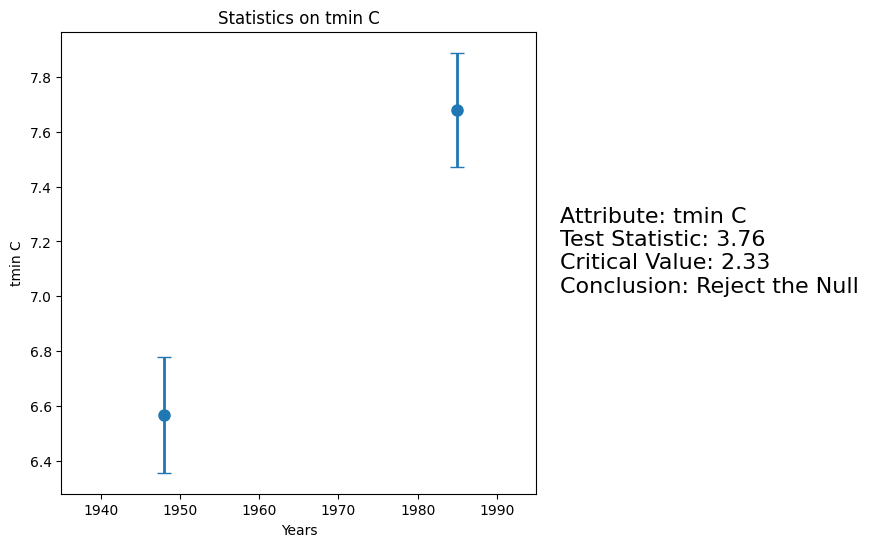

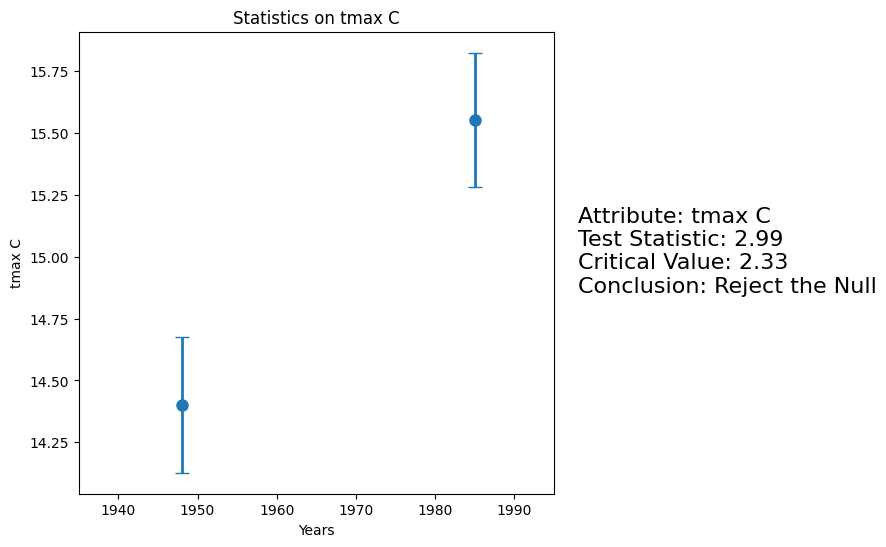

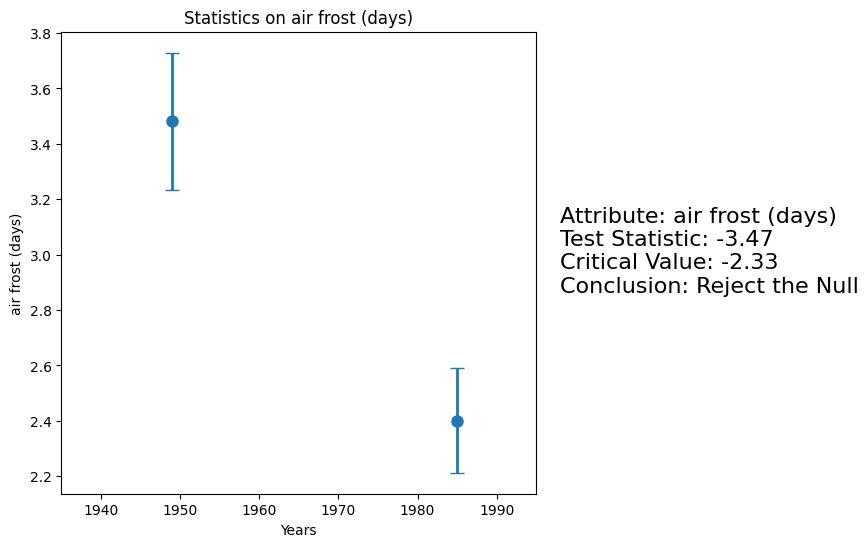

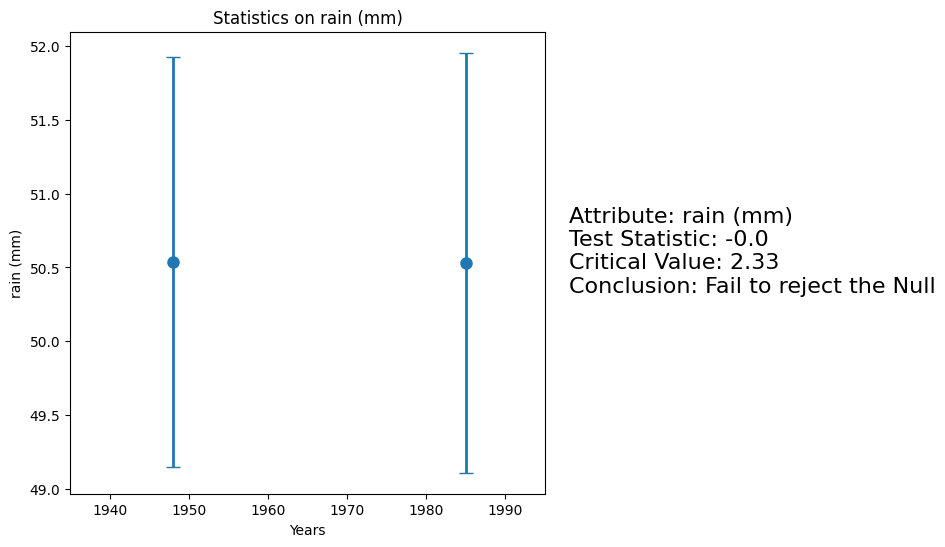

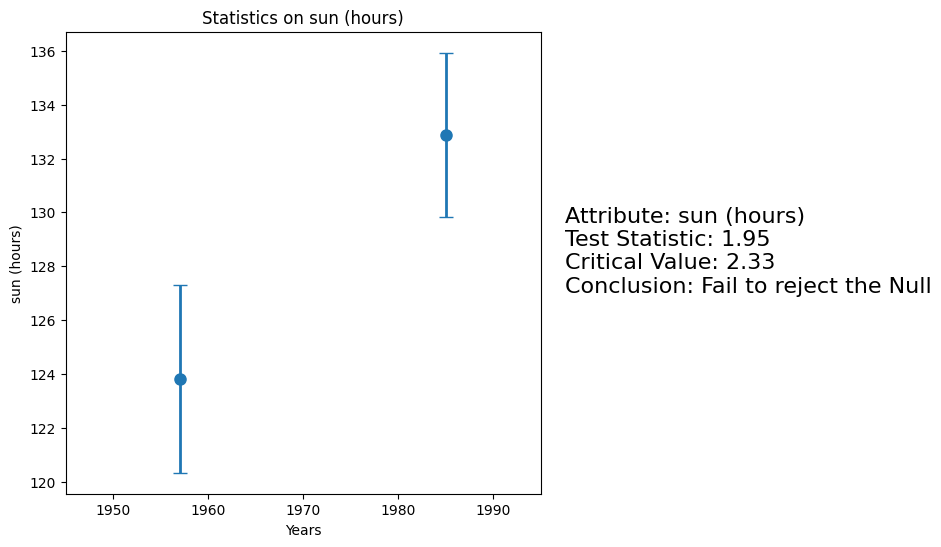

In [42]:
# tmin C – upper-tail test
test(df, "tmin C", 1, split_idx, cv_upper)

# tmax C – upper-tail test
test(df, "tmax C", 1, split_idx, cv_upper)

# air frost (days) – lower-tail test
test(df, "air frost (days)", af_start, split_idx, cv_lower)

# rain (mm) – upper-tail test
test(df, "rain (mm)", 1, split_idx, cv_upper)

# sun (hours) – upper-tail test
test(df, "sun (hours)", sun_start, split_idx, cv_upper)


# Appendices

## Appendix A: Z-tests, t-tests and getting critical values

For a z-test, you will need properties from the normal distribution. For a t-test, you will need properties of the Student-t distribution. There are many to get these in python. One way is to use `scipy.stats`. You can `from scipy import stats` which gives you all of stats, or just import the normal distribution, which is called norm - `from scipy.stats import norm`, or import the t-distribution, `from scipy.stats import t`. 

### Z tests

The normal distribution is denoted `norm` in `scipy.stats`, with `loc` as the mean and `scale` as the standard deviation. For example, `norm.pdf(3,loc=0,scale=1)` would give the value of the normal distribution at $3$ with mean $0$ and standard deviation $1$. The defaults of `loc` and `scale` are $0$ and $1$, so `norm.pdf()` is the pdf of the "standard" normal distribution. 

## Two-tailed test

The confidence interval is a function of $\alpha$
 and is the smallest interval which contains $1-\alpha$
of the probability. For a two-tailed test, if the test statistic is outside
the confidence interval, the null hypothesis is rejected; if it is inside the confidence interval, the null hypothesis is not rejected. All distributions in `scipy.stats` have a method `interval` which computes confidence interval.

### One tail test
Here is where `ppf` (the inverse of the cumulative distribution) is very useful. The lower tail critical value is where the cumulative distribution is equal to $\alpha$. The upper tail critical value is where the cumulative distribution is equal to $1-\alpha$. For a symmetric distribution (such as the normal or t distributions) the two critical values will be the same magnitude, but the lower tail critical value will be negative and the upper-tail critical value will be positive. In general they will have different magnitudes.

**Example:** 
`alpha = 0.05`
`norm.ppf(alpha)`
gives the location of the lower $5\%$ tail of the standard normal distribution. 

## Students-t test

The t-distribution works in a similar way, except the so-called "shape parameter" is the number of degrees of freedom, rather than the variance, and the location parameter (the mean) comes after the degrees of freedom. Comparing two means the degrees is size of dataset1 + size of dataset2 -2.

## Appendix Bootstrap test

The way to determine the statistical significance between two data sets, `data1` and `data2`, is as follows:

  1. Measure the difference between the two data sets `Delta = data2.mean() - data1.mean()`.
  
  2. Repeat $N$ times, 
  
    i. Create a bootstrap sample of `data1` with the same size as `data1`. Call it `BS1`.
    
    ii. Create a bootstrap sample of `data2` with the same size of `data2`. Call it `BS2`.
    
    iii. Observe the difference between the mean of `BS2` and the mean of `BS1`. Call it BSDelta.
    
    iv. For an upper tail test, count the number times that `BSDelta` is greater than or equal to `Delta`.
    
    v. For a lower tail test, count the number of times that `BSDelta` is less than or equan to `Delta"
   
   3. That count divided by $N$ is the $p$-value. Compare it to $\alpha$ to determine the result. 
    
    